In [1]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("Powerplant_dataset.csv")

In [6]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
# AT - temperature
# V - vaccum
# AP - pressure
# RH - humadity
# PE - produced energy


In [7]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [9]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [10]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
df.shape

(9568, 5)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [18]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [19]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Deep Learning

In [42]:
# Define ANN Model
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
    
        self.model = nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output Layer
            nn.Linear(6, 1),
        )
    
    def forward(self, x):
        return self.model(x)

In [43]:
import torch.optim as optim
model = ANN()

# loss, optimizer

crietrion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [44]:
# Train the ANN
train_losses = []
val_losses = []
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0 # tot training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = labels of 1 batch
        optimizer.zero_grad()

        outputs = model(xb) # forward prop....predicted outputs for this batch
        loss = crietrion(outputs, yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradients compute
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = crietrion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

epoch 1/100 ==> train loss = 206142.7666015625 & val loss = 204936.02890625
epoch 2/100 ==> train loss = 200543.60091145834 & val loss = 192908.00442708333
epoch 3/100 ==> train loss = 179254.0087890625 & val loss = 162378.22395833334
epoch 4/100 ==> train loss = 141645.53720703124 & val loss = 120567.14388020833
epoch 5/100 ==> train loss = 101044.90966796875 & val loss = 84763.70924479167
epoch 6/100 ==> train loss = 72066.96116536458 & val loss = 62279.373697916664
epoch 7/100 ==> train loss = 53035.03457845052 & val loss = 45658.3412109375
epoch 8/100 ==> train loss = 37422.27775065104 & val loss = 30335.60322265625
epoch 9/100 ==> train loss = 23220.713956705727 & val loss = 17374.104117838542
epoch 10/100 ==> train loss = 12557.15990600586 & val loss = 8913.793798828125
epoch 11/100 ==> train loss = 6623.189667765299 & val loss = 5187.535148111979
epoch 12/100 ==> train loss = 4319.150388590495 & val loss = 3824.407275390625
epoch 13/100 ==> train loss = 3324.628476969401 & val l

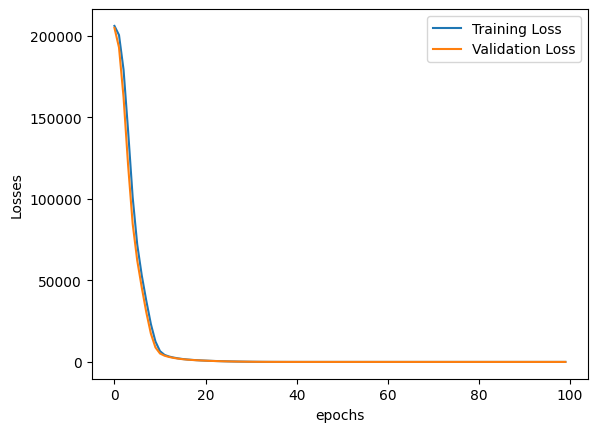

In [45]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})
plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("epochs")
plt.ylabel("Losses")
plt.legend()
